# BERT WordPiece

WordPiece는 단어 전체가 어휘에 없을 때 고정된 어휘에 등록된 더 작은 조각으로 나누는 서브워드 토큰화 방식이다. 단어 단위 어휘가 처음 보는 활용형이나 합성어를 통째로 OOV로 처리하는 문제를 줄이기 위해 사용한다.

## BERT
**BERT(Bidirectional Encoder Representations from Transformers)** 는 문장의 앞뒤 문맥을 함께 읽어 단어와 문장의 의미를 벡터로 표현하는 사전학습 언어 모델이다.

**BERT 특징**

- Transformer Encoder 사용: 각 토큰이 문장 안의 다른 모든 토큰을 참고하여 자신의 벡터를 갱신하는 Self-Attention으로 단어 관계를 분석
- 양방향 문맥 사용: 특정 단어의 앞과 뒤를 함께 참고
- 사전학습 모델: 대량의 문서로 기본적인 언어 표현을 미리 학습
- 전이학습 가능: 소량의 데이터로 감성 분류, 문장 분류, 개체명 인식 등에 활용

## 토큰 분할 방식

- **고정 어휘**: 학습이 끝난 토크나이저는 어휘와 토큰 ID를 고정하여 같은 전처리 조건의 문자열을 같은 조각과 ID로 바꾼다.
- **Longest-match 분할**: 단어의 앞부분부터 시작하여 현재 위치에서 어휘에 존재하는 가장 긴 조각을 우선 선택한다. '안녕'과 '안녕하'가 있으면 '안녕하'를 선택.
- **연속 조각 `##`**: `##`로 시작하는 조각은 공백 뒤의 새 단어가 아니라 앞 조각과 같은 원래 단어 안에서 이어지는 부분이다.
- **OOV(Out-Of-Vocabulary)**: 현재 어휘의 어떤 조각으로도 표현할 수 없는 입력이라는 현상이다.
- **`[UNK]`(Unknown Token)**: BERT가 OOV 입력을 대신하도록 실제 어휘에 예약한 특수 토큰이다.

## BERT 입력에서의 역할

WordPiece 토크나이저는 문자열을 조각으로 나누는 데서 끝나지 않고, BERT가 학습할 때 사용한 입력 형식에 맞춰 정수 텐서를 만든다. 토크나이저와 모델은 어휘 ID와 임베딩 행을 공유하는 한 쌍이므로 반드시 같은 checkpoint의 파일을 사용해야 한다.

`OOV`는 어휘에 없는 입력을 가리키는 용어이고, `[UNK]`는 BERT가 그 입력을 대신할 때 사용하는 실제 토큰 이름이다. `[UNK]`를 임의로 `[OOV]`로 바꾸면 checkpoint의 어휘 ID와 맞지 않으므로 BERT 입력에서는 그대로 사용한다.

- **`input_ids`**: WordPiece 조각과 `[CLS](단어/문장의 시작을 나타내는 토큰)`·`[SEP](단어/문장의 끝을 나타내는 토큰)`·`[PAD]`를 어휘의 정수 ID로 바꾼 입력이다.
- **`attention_mask`**: BERT가 읽을 실제 토큰은 1, 계산에서 제외할 PAD 위치는 0으로 표시한다.
- **`token_type_ids`**: 하나의 입력 안에서 첫 번째 문장과 두 번째 문장 구간을 구분한다.
- **`[MASK]`**: BERT가 가려진 토큰을 예측하도록 사전학습할 때 사용하는 특수 토큰이다.

## 장점과 한계

- **장점**
  - 단어 단위 어휘보다 OOV를 줄이면서 어휘 크기를 제한할 수 있다.
  - 사전학습 BERT와 같은 토큰 ID 규칙을 사용하여 입력을 모델의 임베딩 행에 정확히 연결한다.
- **한계**
  - 어떤 조각 조합으로도 표현할 수 없는 OOV 입력은 BERT의 `[UNK]`가 되며, 분할 결과가 항상 형태소나 의미 단위와 일치하지는 않는다.
  - checkpoint마다 어휘와 ID가 다를 수 있으므로 다른 모델의 토크나이저를 섞어 사용할 수 없다.

## 대표 사용처

BERT와 이를 바탕으로 만든 텍스트 분류, 질의응답, 개체명 인식 모델의 입력을 준비할 때 사용한다.

## 이번 노트북에서 확인할 내용

`klue/bert-base`의 WordPiece 토크나이저로 문자열을 조각과 ID로 바꾸고, 특수 토큰과 패딩을 포함한 `BatchEncoding`을 만든다.
이 입력을 같은 checkpoint의 BERT에 전달하여 `(배치, 토큰 위치, 은닉 특성)` 구조의 `last_hidden_state`가 만들어지는 과정까지 확인한다.


## 01. 단어 단위 UNK에서 WordPiece로

단어 단위 토큰화는 공백으로 나눈 단어 전체를 어휘의 한 항목으로 취급한다. 어휘에 `재미`와 `있다`가 따로 있어도 새로운 입력 `재미있다`가 한 항목으로 등록되어 있지 않으면 OOV가 된다. 활용형과 합성어를 모두 어휘에 넣기는 어렵기 때문에 입력 정보가 쉽게 사라진다.

WordPiece는 단어를 고정 어휘에 있는 더 작은 조각으로 나눈다. 현재 위치에서 어휘에 존재하는 가장 긴 조각을 우선 찾으므로, 단어 전체가 처음 등장해도 부분 조각이 등록되어 있으면 여러 ID로 표현할 수 있다.

아래 코드의 `word_vocab`은 단어 단위 OOV를 보여 주기 위해 임의로 만든 작은 예제이며 `klue/bert-base`의 실제 어휘와는 별개이다. 이 예제에서는 미등록 단어를 `[UNK]`로 바꾼다. 사전학습 WordPiece 결과와 나란히 출력하여 `재미있다`가 통째로 `[UNK]`가 되는 경우와 `재미있`, `##다`로 보존되는 경우를 비교한다.


In [8]:
import warnings
warnings.filterwarnings("ignore", message="IProgress not found.*")

from transformers import AutoTokenizer
from transformers import logging as transformers_logging
from huggingface_hub import logging as huggingface_logging

# 모델 다운로드 시 진행 메시지(로그)를 줄이기 위한 설정 (자세히 해석 안해도 됨)
transformers_logging.set_verbosity_error()
transformers_logging.disable_progress_bar()
huggingface_logging.set_verbosity_error()

# 토크나이저와 뒤에서 불러올 BERT 모델은 같은 체크포인트를 사용한다.
# KLUE BERT: 한국어 자연어를 학습한 토큰화 모델
MODEL_NAME = "klue/bert-base"

# 사전학습된 모델을 다운로드
# - AutoTokenizer: 모델의 이름을 읽어 알맞은 토크나이저 클래스와 사전을 다운로드 또는 불러오기 하는 객체
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

text = "영화가 재미있다"

# 이 작은 단어 어휘는 단어 단위 OOV를 보여 주는 비교 기준이며 BERT의 실제 어휘와는 다르다.
word_vocab = {"영화가", "재미", "있다"}
word_level_tokens = [
    word if word in word_vocab else "[UNK]"
    for word in text.split()
]

# WordPiece는 같은 문장을 사전학습 어휘의 더 작은 조각으로 나눈다.
wordpiece_tokens = tokenizer.tokenize(text)

print("원문:", text)
print("예제 단어 어휘:", sorted(word_vocab))
print("단어 단위 결과:", word_level_tokens)
print("WordPiece 결과:", wordpiece_tokens)
# 두 출력 목록을 비교해 단어 단위 UNK가 WordPiece 조각으로 보존되는지 확인한다.

원문: 영화가 재미있다
예제 단어 어휘: ['영화가', '있다', '재미']
단어 단위 결과: ['영화가', '[UNK]']
WordPiece 결과: ['영화', '##가', '재미있', '##다']


## 02. `##` 조각과 토큰 ID 읽기

`##`는 원문에 있던 문자가 아니라 현재 조각이 앞 조각과 같은 단어 안에서 이어진다는 경계 표시이다. `영화`, `##가`는 두 단어가 아니라 원래 단어 `영화가`의 두 조각이다. 공백 뒤에서 새 단어가 시작되는 `재미있`에는 `##`가 붙지 않고, 그 뒤에 이어지는 `다`에는 `##`가 붙는다.

토큰 ID는 조각의 중요도나 빈도를 나타내는 점수가 아니라 현재 WordPiece 어휘의 행 번호이다. 문자열 조각을 사람이 읽을 때와 BERT가 정수 입력을 받을 때 같은 위치를 연결하기 위해 두 목록을 함께 확인해야 한다.

아래 코드에서 `tokens[i]`와 `token_ids[i]`는 같은 조각의 문자열과 정수 표현이다. `convert_ids_to_tokens()`로 ID를 다시 조회했을 때 처음 조각 목록과 같아야 위치 대응이 유지된 것이다. 이 ID는 다음 절에서 특수 토큰과 결합되어 BERT의 `input_ids`가 된다.


In [2]:
# 특수 토큰을 붙이기 전 WordPiece 조각을 KLUE BERT 어휘의 ID로 바꾼다.
tokens = tokenizer.tokenize(text)  # 위에 WordPiece 결과에 따라 ['영화', '##가', '재미있', '##다'] 로 쪼개짐.
token_ids = tokenizer.convert_tokens_to_ids(tokens) # 토큰 ID 목록

print("위치별 조각과 ID")
for position, (token, token_id) in enumerate(zip(tokens, token_ids)):
    print(f"{position}: {token:8} -> {token_id}")

# ID를 다시 조회해 같은 WordPiece 조각으로 복원되는지 확인한다.
restored_tokens = tokenizer.convert_ids_to_tokens(token_ids)
print("ID에서 복원한 조각:", restored_tokens)


위치별 조각과 ID
0: 영화       -> 3771
1: ##가      -> 2116
2: 재미있      -> 6001
3: ##다      -> 2062
ID에서 복원한 조각: ['영화', '##가', '재미있', '##다']


## 03. BERT 특수 토큰과 Attention Mask

BERT는 WordPiece로 나눈 원문 토큰과 함께 입력의 시작·끝·빈자리를 나타내는 특수 토큰을 사용한다. 특수 토큰도 일반 토큰처럼 어휘 사전에 등록되어 있으며 고유한 ID를 가진다.

- **`[CLS]`**: 입력의 맨 앞에 추가되는 토큰이다. 문장 분류에서는 이 위치의 최종 벡터를 문장 전체의 표현으로 사용할 수 있다.
- **`[SEP]`**: 문장의 끝이나 두 문장의 경계를 표시한다.
- **`[PAD]`**: 길이가 다른 문장을 하나의 배치로 묶을 때 빈자리를 채운다.
- **`[UNK]`**: WordPiece 어휘의 어떤 조각으로도 표현하지 못한 입력을 대신한다.
- **`[MASK]`**: BERT가 가려진 원래 토큰을 예측하도록 사전학습할 때 사용하는 토큰이다.

### Attention Mask

Attention Mask는 특수 토큰이 아니라, **BERT가 처리할 위치와 무시할 위치를 구분하는 숫자 배열**이다.

```text
토큰:            [CLS] 영화 ##가 [SEP] [PAD] [PAD]
attention_mask:     1    1    1     1     0     0
```

- `1`: BERT가 읽어야 하는 위치
- `0`: 길이만 맞추기 위해 추가된 `[PAD]` 위치

`[CLS]`, `[SEP]`, `[MASK]`는 BERT가 의미를 처리해야 하는 토큰이므로 Attention Mask에서 `1`이 된다. `[PAD]`만 실제 내용이 없는 자리이므로 `0`이 된다.

> `[MASK]`는 문장 안에 들어가는 실제 토큰이고, `attention_mask`는 BERT가 읽을 위치를 표시하는 별도의 숫자 배열이다.

### Special Tokens Mask

`special_tokens_mask`는 토큰화 결과에서 특수 토큰의 위치를 확인하기 위한 참고 배열이다.

```text
토큰:                   [CLS] 영화 ##가 [SEP] [PAD] [PAD]
special_tokens_mask:       1    0    0     1     1     1
```

이 값은 토큰 구성을 확인하거나 후처리할 때 사용할 수 있지만, 현재 실습에서는 BERT 모델에 직접 전달하지 않는다.

아래 코드는 WordPiece 토큰에 `[CLS]`, `[SEP]`, `[PAD]`를 추가하고 전체 길이를 12로 맞춘다. 실행 결과에서는 각 위치의 토큰, ID와 Attention Mask를 함께 비교하여 실제 토큰 위치는 `1`, `[PAD]` 위치는 `0`인지 확인한다.

In [5]:
special_tokens = ["[PAD]", "[UNK]", "[CLS]", "[SEP]", "[MASK]"]

# 특수 토큰 문자열을 key, 어휘표에서 조회한 정수 ID를 value로 저장한다.
# 이 ID들은 KLUE BERT가 학습할 때 사용한 약속이며 다른 BERT 모델에서는 번호가 다를 수 있다.
special_token_ids = {
    token: tokenizer.convert_tokens_to_ids(token)
    for token in special_tokens
}

print("특수 토큰 ID:", special_token_ids)

# 한국어 어휘로 표현할 수 없는 실험 기구 이모지가 단일 [UNK] ID로 바뀌는 것을 확인한다
text = "영화가 재미있다 🧪"

# "영화가 재미있다 🧪"를 KLUE BERT를 이용해서 토큰화
unknown_example_tokens = tokenizer.tokenize(text)
print("[UNK] 예시:", unknown_example_tokens)

# KLUE BERT 직접 호출 -> 문자열 분할부터 ID 변환, 특수토큰([CLS], [SEP]) 추가
# 토큰 개수 자르기, 부족한 칸에 [PAD] 채우기까지 모두 한 번에 수행
encoded = tokenizer(
    text,
    padding="max_length", # 토큰이 max_length 미만이면 [PAD] 채우기
    truncation=True,  # max_length 초과 시 자르기
    max_length=12,
    return_special_tokens_mask=True, # 특수토큰 1, 나머지 0 목록도 같이 반환
)

print(encoded)

특수 토큰 ID: {'[PAD]': 0, '[UNK]': 1, '[CLS]': 2, '[SEP]': 3, '[MASK]': 4}
[UNK] 예시: ['영화', '##가', '재미있', '##다', '[UNK]']
{'input_ids': [2, 3771, 2116, 6001, 2062, 1, 3, 0, 0, 0, 0, 0], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0], 'special_tokens_mask': [1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1]}


## 04. 여러 문장을 하나의 배치로 만들기

신경망의 한 배치는 여러 문장을 하나의 직사각형 텐서로 묶으므로 모든 행의 길이가 같아야 한다. 짧은 문장에는 `[PAD]`를 추가하고 최대 길이를 넘는 문장은 뒤쪽 조각을 잘라, 두 문장을 모두 길이 12로 맞춘다.

`return_tensors="pt"`를 지정하면 토크나이저의 목록 결과가 PyTorch Tensor를 담은 `BatchEncoding`으로 바뀐다. 주요 항목의 shape는 모두 `(배치 2, 토큰 위치 12)`이다.

- **`input_ids`**: 각 위치의 WordPiece와 특수 토큰 ID이다.
- **`attention_mask`**: 실제로 읽을 위치는 1, PAD 위치는 0이다.
- **`token_type_ids`**: 한 입력 안의 첫 문장과 둘째 문장을 0과 1로 구분한다. 현재 배치의 각 행은 단일 문장이므로 모두 0이다.
```text
[CLS] 첫 번째 문장 [SEP] 두 번째 문장 [SEP]
   0      0       0       1       1
```

아래 출력에서는 짧은 첫 문장에 PAD가 더 많이 붙어도 네 Tensor의 shape가 같은지 확인한다. `attention_mask`의 합계는 각 문장에서 BERT가 읽을 CLS·원문 조각·SEP 위치의 수이다.


In [6]:
batch_texts = [
    "영화가 재미있다",
    "영화가 재미있지만 결말은 아쉬웠다",
]

# 문장 두 개를 길이 12로 패딩하고 BERT가 받는 PyTorch 정수 텐서로 변환한다.
batch_encoding = tokenizer(
    batch_texts,
    padding="max_length",
    truncation=True,
    max_length=12,
    return_tensors="pt",
    return_special_tokens_mask=True,
)

# 각 텐서의 첫 축은 문장 수 2, 둘째 축은 토큰 위치 수 12이다.
for key, tensor in batch_encoding.items():
    print(f"{key:20}: shape={tuple(tensor.shape)}")

for row_index, sentence in enumerate(batch_texts):
    row_ids = batch_encoding["input_ids"][row_index].tolist()
    row_tokens = tokenizer.convert_ids_to_tokens(row_ids)
    row_mask = batch_encoding["attention_mask"][row_index].tolist()
    print(f"\n문장 {row_index + 1}: {sentence}")
    print("tokens:", row_tokens)
    print("attention_mask:", row_mask)
    print("모델이 읽을 위치 수:", sum(row_mask))


input_ids           : shape=(2, 12)
token_type_ids      : shape=(2, 12)
attention_mask      : shape=(2, 12)
special_tokens_mask : shape=(2, 12)

문장 1: 영화가 재미있다
tokens: ['[CLS]', '영화', '##가', '재미있', '##다', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
attention_mask: [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0]
모델이 읽을 위치 수: 6

문장 2: 영화가 재미있지만 결말은 아쉬웠다
tokens: ['[CLS]', '영화', '##가', '재미있', '##지만', '결말', '##은', '아쉬웠', '##다', '[SEP]', '[PAD]', '[PAD]']
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0]
모델이 읽을 위치 수: 10


## 05. BERT에 입력하여 문맥 벡터 얻기

`input_ids`, `attention_mask`, `token_type_ids`는 앞 절에서 만든 `BatchEncoding` 중 BERT가 실제로 받는 세 Tensor이다.
- `input_ids`는 토큰 임베딩 행을 선택하고,
- attention mask는 내용 토큰이 PAD를 참고하지 않게 하며,
- token type ID는 문장 쌍의 두 구간을 구분한다.

`AutoModel.from_pretrained("klue/bert-base")`는 분류 출력층 없이 `klue/bert-base`의 사전학습 Encoder를 불러온다.
토크나이저와 모델의 checkpoint 이름이 같아야 input ID가 학습된 올바른 임베딩 행을 선택한다.

### 768은 어디에서 나오는가

`klue/bert-base`는 각 토큰을 768개의 값으로 표현하도록 설계되고 사전학습된 모델이다. 이 크기를 `hidden_size`라고 하며 입력 데이터에서 계산되는 값이 아니라 모델 구조에 미리 정해진 설정이다.

토큰 ID는 크기가 `(어휘 수, 768)`인 임베딩 가중치에서 해당 행을 선택한다. 위치 임베딩과 문장 구간 임베딩도 더해지며, BERT Encoder를 통과하는 동안 각 토큰 벡터의 크기는 768로 유지된다.

### Self-Attention으로 다른 토큰 정보가 반영되는 과정

BERT에 입력하기 전의 `[CLS]`는 문장 내용을 요약한 벡터가 아니다. 모든 문장 맨 앞에 같은 ID로 추가하는 특수 토큰이며, 처음에는 문장마다 다른 내용을 가지고 있지 않다.

Self-Attention은 각 토큰이 문장 안의 다른 모든 토큰을 비교하고, 관련도가 높은 토큰의 정보는 많이, 낮은 토큰의 정보는 적게 더하여 자신의 벡터를 새로 만드는 연산이다. 이 연산은 `[CLS]`를 포함한 모든 토큰 위치에 적용된다.

```text
입력:       [CLS]  영화가  정말  재미있다  [SEP]
                       ↓ Self-Attention
[CLS] 출력: [CLS] 자체 정보 + 영화가 정보 + 정말 정보 + 재미있다 정보
```

따라서 BERT를 통과한 뒤에는 모든 토큰의 출력 벡터에 주변 토큰 정보가 반영된다. 그중 `[CLS]`는 문장 분류에 사용하기로 정한 대표 위치이므로 `last_hidden_state`의 0번 위치를 선택한다. 이 벡터만으로 긍정·부정 점수가 바로 나오는 것은 아니며, 감성 분류 데이터로 학습한 분류 헤드를 추가해야 한다.

이 코드에서 shape는 다음과 같이 변한다.

- **BERT 입력**: `(배치 2, 토큰 위치 12)`의 정수 Tensor 세 개이다.
- **`last_hidden_state`**: 각 위치에 문맥이 반영된 768차원 벡터를 가진 `(2, 12, 768)` Tensor이다.
- **`cls_vectors`**: BERT를 통과한 뒤 모든 문장의 0번 `[CLS]` 위치를 선택한 `(2, 768)` Tensor이다. 문장 분류 헤드의 입력으로 사용할 수 있지만 현재 코드에서는 분류 점수를 만들지 않는다.

PAD 위치에도 출력 벡터는 만들어지지만 실제 내용으로 해석하지 않는다. 토큰 평균처럼 여러 위치를 합칠 때는 attention mask를 사용해 PAD 출력을 별도로 제외해야 한다.

```
문장
↓
klue/bert-base 토크나이저
↓
WordPiece 토큰·토큰 ID·Attention Mask
↓
klue/bert-base 사전학습 BERT 모델
↓
각 토큰의 문맥이 반영된 768차원 벡터
```

In [7]:
import torch

# AutoModel: 사전학습된 BERT Encoder 본체(모델) 가져오기
from transformers import AutoModel

# 토큰 ID가 올바른 임베딩 행을 가리키도록 토크나이저와 같은 체크포인트를 불러온다.
bert_model = AutoModel.from_pretrained(MODEL_NAME)  # KLUE BERT

# 가져온 모델을 평가 모드로 전환
bert_model.eval()

# special_tokens_mask는 설명용이므로 제외하고 BERT가 받는 세 텐서만 선택한다.
# batch_encoding: 위쪽 코드셀에 만들어진 Tokenizer 결과물
model_inputs = {
    key: batch_encoding[key]
    for key in ("input_ids", "attention_mask", "token_type_ids")
}

# 토큰화 결과를 딥러닝 모델의 파라미터로 전달
with torch.inference_mode():
    model_output = bert_model(**model_inputs)

# last_hidden_state의 shape는 `(배치 2, 토큰 위치 12, 은닉 특성 768)`이다.
last_hidden_state = model_output.last_hidden_state


# Self-Attention: BERT 모델을 이용해서 만든 토큰 벡터를 일정 비율로 섞어서 새 벡터를 만드는 과정
# BERT를 통과한 [CLS] 출력에는 Self-Attention으로 다른 토큰 정보가 반영되어 있다.
# 모든 문장의 0번 위치를 선택하면 `(2, 768)`이 되지만 현재 코드에서는 분류 점수를 만들지 않는다.
cls_vectors = last_hidden_state[:, 0, :]

print("input_ids shape:", tuple(model_inputs["input_ids"].shape))
print("attention_mask shape:", tuple(model_inputs["attention_mask"].shape))
print("last_hidden_state shape:", tuple(last_hidden_state.shape))
print("CLS 벡터 shape:", tuple(cls_vectors.shape))
print("BERT 은닉 차원:", bert_model.config.hidden_size)


# input_ids shape: (2, 12)   -> 입력 2문장, 각 토큰 12개
# attention_mask shape: (2, 12)  -> 입력 2문장에 대한 attention_mask(12칸)
# last_hidden_state shape: (2, 12, 768)  -> 입력 2문장, 각 토큰 12.  토큰당 임베딩 벡터값 768
# CLS 벡터 shape: (2, 768)  ->
# BERT 은닉 차원: 76


input_ids shape: (2, 12)
attention_mask shape: (2, 12)
last_hidden_state shape: (2, 12, 768)
CLS 벡터 shape: (2, 768)
BERT 은닉 차원: 768


## 06. 결과에서 주목할 점

결과를 읽을 때는 토큰화와 BERT Encoder를 분리한 뒤, 앞 단계의 출력이 다음 단계의 입력으로 이어지는지 확인한다.

- 단어 단위 어휘에서 OOV였던 `재미있다`가 `재미있`, `##다`로 보존되는지 확인한다.
- `##` 조각을 별도 단어가 아니라 앞 조각의 연속으로 읽고, 문자열 조각과 ID를 같은 위치끼리 연결한다.
- CLS와 SEP의 attention mask는 1이고 PAD 위치만 0인지 확인한다.
- `(2, 12)`의 정수 입력이 `(2, 12, 768)`의 문맥 벡터와 `(2, 768)`의 CLS 벡터로 바뀌는지 확인한다.

전체 흐름은 `문자열 → WordPiece 조각 → 특수 토큰 추가 → BatchEncoding → BERT 문맥 벡터`이다. 이 노트북은 WordPiece 어휘를 새로 학습하지 않고, 사전학습된 `klue/bert-base`의 토크나이저·모델 약속을 그대로 사용한다. 이후 BERT 모델에서도 두 checkpoint 이름을 같게 유지해야 토큰 ID가 올바른 임베딩 행을 선택한다.

### 확인 질문

1. `재미있`, `##다`에서 `##다`를 독립된 단어라고 부르면 왜 잘못인가?
2. `[MASK]` 토큰과 attention mask는 각각 무엇을 표시하는가?
3. 짧은 문장의 PAD 위치에서 attention mask를 1로 두면 내용 토큰의 문맥 벡터에 어떤 문제가 생길 수 있는가?
4. BERT 입력 전의 `[CLS]` 토큰과 Self-Attention을 통과한 뒤의 `[CLS]` 출력 벡터는 어떻게 다른가?

아래 그림은 WordPiece 조각이 특수 토큰을 포함한 BERT 입력과 문맥 벡터로 이어지는 과정을 보여 준다. 표 위의 1~12는 사람이 읽기 위한 순번이며 코드의 `[:, 0, :]`은 0부터 세는 텐서 인덱스에서 첫 `[CLS]` 위치를 선택한다. `special_tokens_mask`는 특수 토큰 위치를 설명하는 값이고 실제 BERT에는 `input_ids`, `attention_mask`, `token_type_ids`를 전달한다.

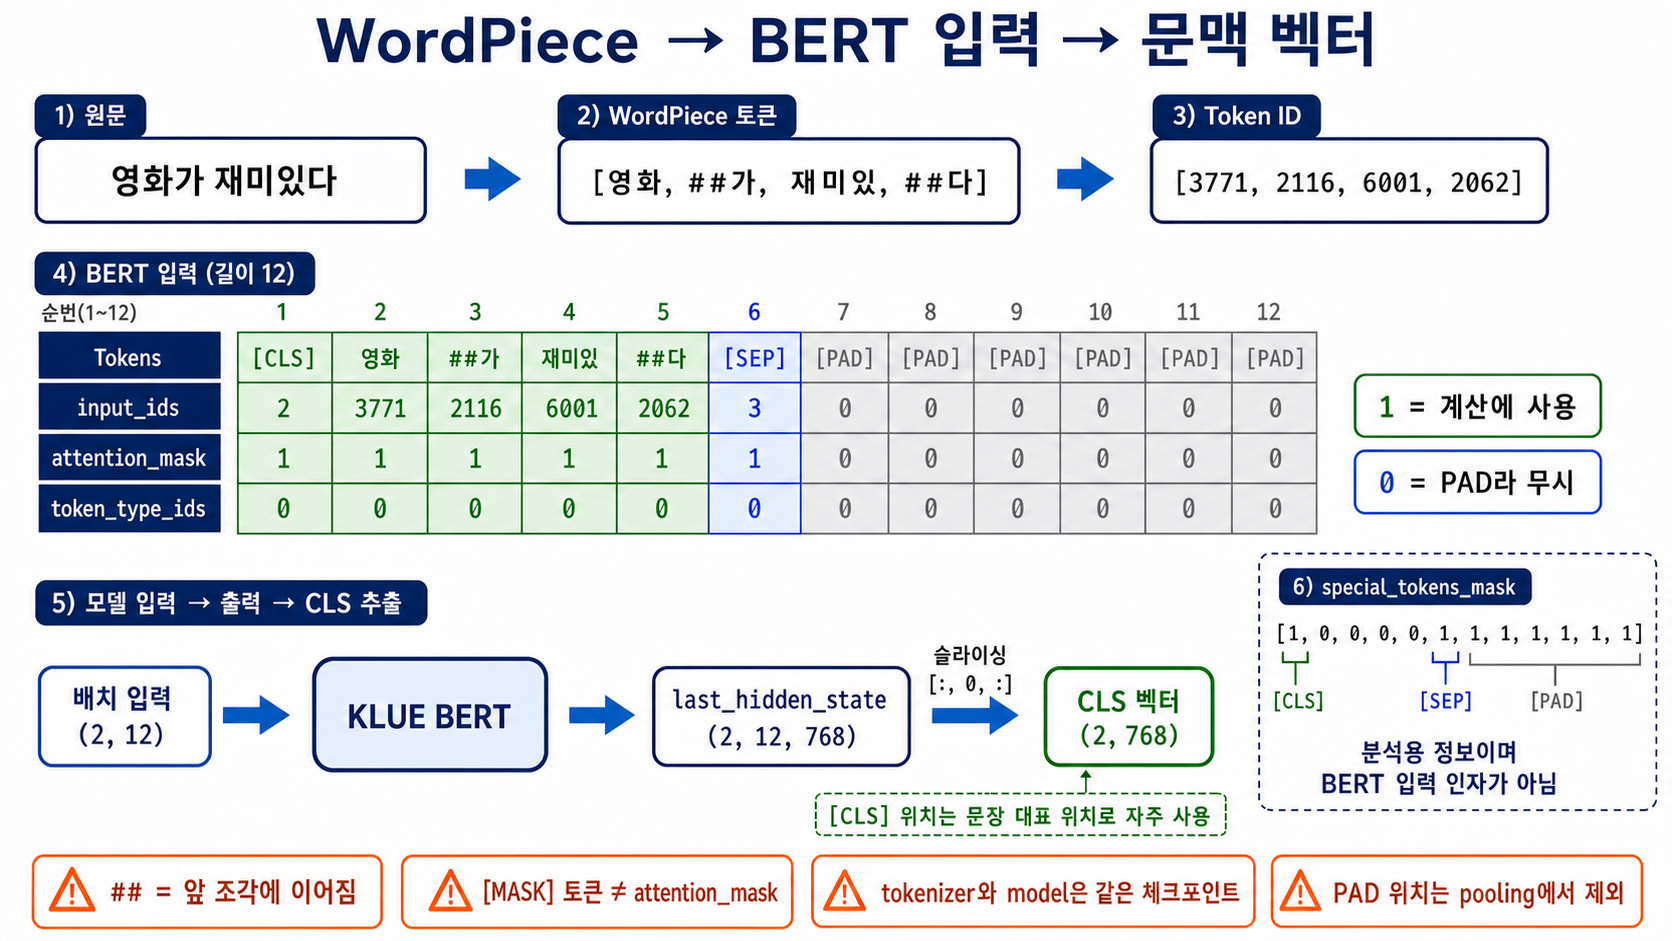
